# 5. Graphs in Finance

### Q5.1: Load the S&P500 data used previously, and choose 10 assets.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("snp_allstocks_2015_2019.csv")
df = df.set_index("Date")

info = pd.read_csv("snp_info.csv")
info.drop(columns=info.columns[0], inplace=True)

sector_picks = {
    "Information Technology": ["AAPL", "MSFT", "GOOGL"],
    "Energy":                 ["XOM",  "CVX",  "PXD"],
    "Financials":             ["JPM",  "GS",   "BLK"],
    "Utilities":              ["NEE",  "DUK",  "SO"],
}

selected_tickers = [t for group in sector_picks.values() for t in group]
sector_labels    = {t: s for s, tickers in sector_picks.items() for t in tickers}

print("Selected stocks:")
for sector, tickers in sector_picks.items():
    print(f"  {sector}: {', '.join(tickers)}")

# Compute log returns
prices = df[selected_tickers].dropna()
log_returns = np.log(prices / prices.shift(1)).dropna()

print(f"\nLog returns shape: {log_returns.shape}")
print(log_returns.head())


Selected stocks:
  Information Technology: AAPL, MSFT, GOOGL
  Energy: XOM, CVX, PXD
  Financials: JPM, GS, BLK
  Utilities: NEE, DUK, SO

Log returns shape: (1005, 12)
                AAPL      MSFT     GOOGL       XOM       CVX       PXD  \
Date                                                                     
2015-01-05 -0.028576 -0.009238 -0.019238 -0.027743 -0.040792 -0.069474   
2015-01-06  0.000094 -0.014786 -0.024989 -0.005330 -0.000463 -0.002650   
2015-01-07  0.013925  0.012625 -0.002945  0.010082 -0.000833 -0.011032   
2015-01-08  0.037703  0.028994  0.003478  0.016508  0.022625  0.024917   
2015-01-09  0.001072 -0.008441 -0.012286 -0.001411 -0.020127  0.007819   

                 JPM        GS       BLK       NEE       DUK        SO  
Date                                                                    
2015-01-05 -0.031537 -0.031721 -0.026215 -0.010648 -0.014501 -0.004263  
2015-01-06 -0.026271 -0.020437 -0.015662  0.003877  0.016284  0.011930  
2015-01-07  0.001525

I asked Claude what would be a good selection of stocks to plot for this exercise, my question and its response are below. I used this response to decide what sectors to select stocks from.

Prompt:
i have these sectors for stocks, which selection would make an interesting correlation graph?

*Answer:*

⏺ To make an interesting correlation graph you want maximum variation in pairwise correlations — some pairs near 1, some near 0, ideally some negative. A uniform blob of moderate positive correlations (which is what you get from one stock per sector) tells you nothing.

The way to get that variation is to think about what drives each sector's returns:

Sectors that move with the market / growth (cyclicals):

- IT — driven by earnings growth, risk appetite
- Financials — driven by interest rates, credit cycles
- Consumer Discretionary — driven by consumer spending
- Industrials — driven by capex cycles

These all tend to correlate positively with each other.

Sectors that move against or independently (defensives/commodities):

- Utilities — driven by bond yields, regulated income; investors rotate into these when markets fall
- Consumer Staples — similarly defensive
- Energy — driven by oil price, largely independent of tech earnings
- Materials — driven by commodity cycles

The most interesting graph comes from picking sectors that sit at opposite ends of this spectrum, so you get:

- High within-group correlation (stocks in the same sector share the same driver)
- Low or negative cross-group correlation (different economic drivers)

The natural choice is:

- IT (growth/risk-on)
- Financials (rates-driven, correlated with IT but distinct)
- Energy (oil-driven, largely independent)
- Utilities (defensive, anti-correlated with Financials especially)

This gives you tight intra-sector clusters and weak/negative inter-sector edges — exactly the structure that makes a graph topologically informative.

### Q5.2: Construct a graph using your selected stocks based on their correlation matrix using `networkx`. Explain the rolw of the correlation matrix and show the results as clearly as possible.

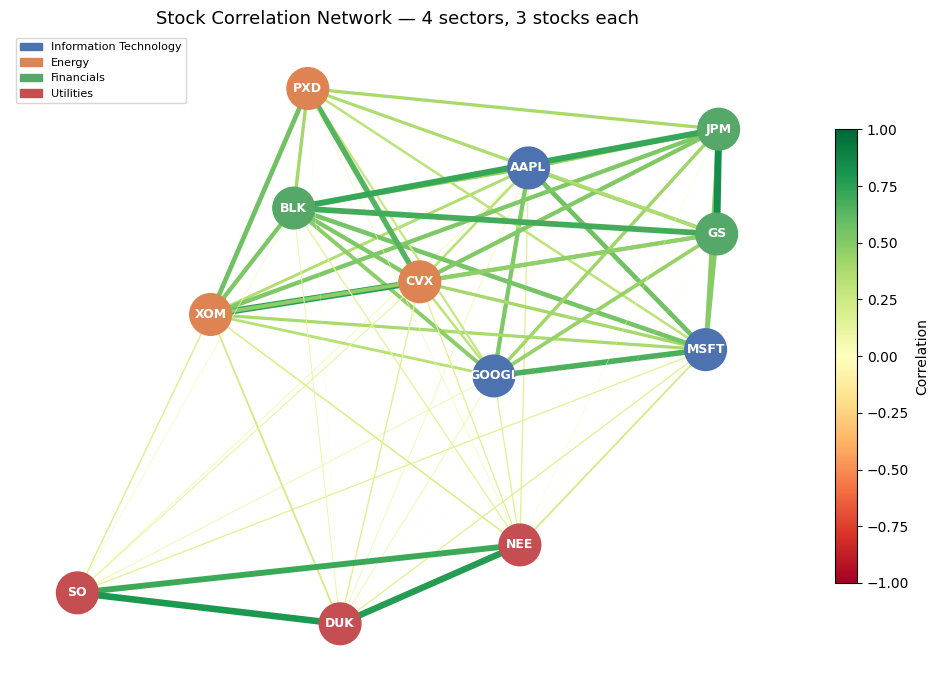

Correlation Matrix:
        AAPL   MSFT  GOOGL    XOM    CVX    PXD    JPM     GS    BLK    NEE    DUK     SO
AAPL   1.000  0.566  0.516  0.356  0.315  0.256  0.426  0.450  0.440  0.162  0.092  0.091
MSFT   0.566  1.000  0.664  0.386  0.402  0.306  0.492  0.494  0.548  0.224  0.160  0.157
GOOGL  0.516  0.664  1.000  0.335  0.306  0.267  0.415  0.450  0.477  0.156  0.101  0.101
XOM    0.356  0.386  0.335  1.000  0.769  0.567  0.518  0.478  0.525  0.196  0.222  0.175
CVX    0.315  0.402  0.306  0.769  1.000  0.648  0.515  0.475  0.516  0.157  0.168  0.129
PXD    0.256  0.306  0.267  0.567  0.648  1.000  0.391  0.372  0.402  0.078  0.030 -0.004
JPM    0.426  0.492  0.415  0.518  0.515  0.391  1.000  0.837  0.720  0.048  0.014 -0.012
GS     0.450  0.494  0.450  0.478  0.475  0.372  0.837  1.000  0.689  0.020 -0.012 -0.022
BLK    0.440  0.548  0.477  0.525  0.516  0.402  0.720  0.689  1.000  0.154  0.104  0.071
NEE    0.162  0.224  0.156  0.196  0.157  0.078  0.048  0.020  0.154  1.000  0.7

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches

# Compute correlation matrix
corr = log_returns.corr()

# Build fully-connected weighted graph
G = nx.Graph()
tickers_list = corr.columns.tolist()
G.add_nodes_from(tickers_list)

for i in range(len(tickers_list)):
    for j in range(i + 1, len(tickers_list)):
        G.add_edge(tickers_list[i], tickers_list[j], weight=corr.iloc[i, j])

# Spring layout: positive weights attract, so clusters will form naturally
pos = nx.spring_layout(G, weight="weight", seed=42)

edges = list(G.edges(data=True))
weights = np.array([d["weight"] for _, _, d in edges])
edge_colors = cm.RdYlGn((weights + 1) / 2)
edge_widths = np.abs(weights) * 6

# Colour nodes by sector
sector_color = {
    "Information Technology": "#4C72B0",
    "Energy":                 "#DD8452",
    "Financials":             "#55A868",
    "Utilities":              "#C44E52",
}
node_colors = [sector_color[sector_labels[t]] for t in tickers_list]

fig, ax = plt.subplots(figsize=(10, 7))
nx.draw_networkx_nodes(G, pos, node_size=900, node_color=node_colors, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, font_color="white", font_weight="bold", ax=ax)
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=edge_colors, ax=ax)

sm = plt.cm.ScalarMappable(cmap=cm.RdYlGn, norm=plt.Normalize(-1, 1))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Correlation", shrink=0.7)

legend_patches = [mpatches.Patch(color=c, label=s) for s, c in sector_color.items()]
ax.legend(handles=legend_patches, loc="upper left", fontsize=8)

ax.set_title("Stock Correlation Network — 4 sectors, 3 stocks each", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig("report_figures/q5_2_correlation_graph.png", dpi=150, bbox_inches="tight")
plt.show()

print("Correlation Matrix:")
print(corr.round(3).to_string())


The correlation matrix is the adjacency matrix of the graph we have plotted, every off-diagonal value is the weight of an edge in the graph.

### Q5.3: Discuss topology, vertex re-ordering, and time-series re-ordering

**Is the topology dictated by the nature of the data?**

Yes, directly. The four clusters (Tech, Energy, Financials, Utilities) emerge because stocks within the same sector share common economic drivers — oil prices, interest rates, consumer demand — so their log returns co-move strongly (ρ = 0.57–0.84 within sector). The spring layout makes this visible: nodes with high mutual correlation are pulled together by attractive edge forces. Conversely, the near-zero and negative correlations between Utilities and Financials (ρ as low as −0.022) cause those clusters to repel, placing them far apart. The topology is therefore a faithful reflection of real-world sectoral structure, not an artefact of the graph algorithm.

**Would re-ordering the graph vertices affect results?**

No. A graph is defined by its node set and edge weights, not by any indexing order. Whether AAPL is listed first or last, the same edges exist with the same weights. The spring layout converges to the same cluster structure regardless of input order (for a fixed seed). Vertex ordering is purely a bookkeeping convention with no effect on topology, edge weights, or the correlation matrix's eigenstructure.

**Would re-ordering the time-series data affect results?**

Shuffling rows (time steps) has no effect on the Pearson correlation matrix, since correlation depends only on the set of paired values and not their temporal ordering — so the graph would be identical. However, this exposes an important limitation: if a different *time window* is chosen, correlations can change substantially. During market stress, cross-sector correlations spike toward 1 as all assets fall together, dissolving the cluster structure. The graph topology is therefore time-dependent, and a single static graph is only a snapshot of one regime. Shuffling columns (assets) merely re-labels nodes and has no structural effect.


### Q5.4: Alternative distance metric — Mantegna distance and Minimum Spanning Tree

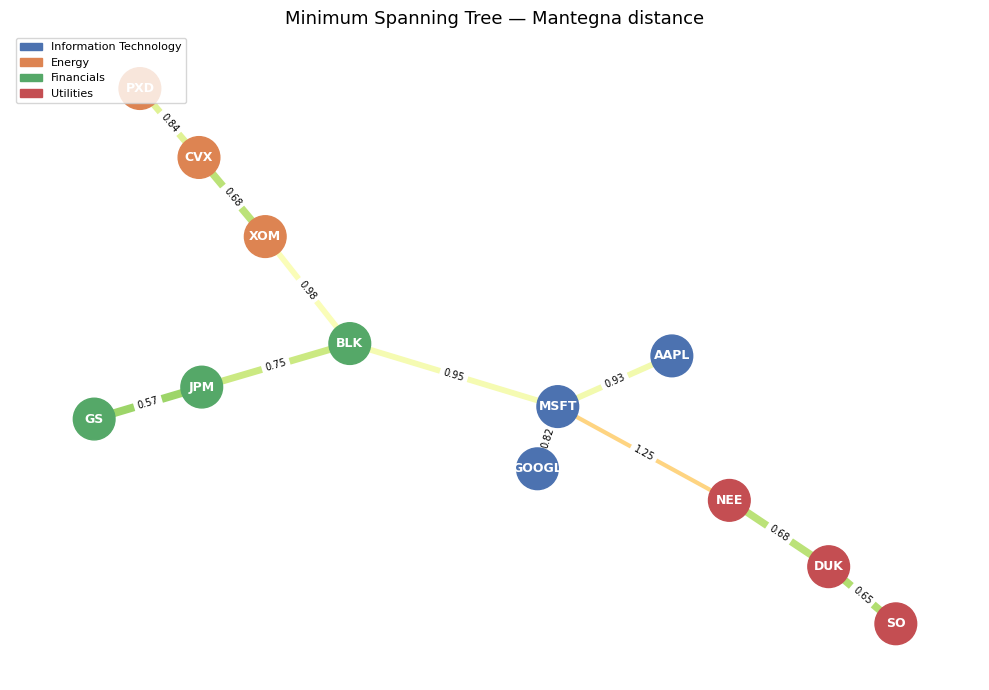

Mantegna distance matrix:
        AAPL   MSFT  GOOGL    XOM    CVX    PXD    JPM     GS    BLK    NEE    DUK     SO
AAPL   0.000  0.932  0.984  1.135  1.170  1.220  1.072  1.048  1.058  1.295  1.348  1.349
MSFT   0.932  0.000  0.819  1.108  1.094  1.178  1.008  1.006  0.951  1.246  1.296  1.299
GOOGL  0.984  0.819  0.000  1.153  1.178  1.211  1.081  1.049  1.023  1.299  1.341  1.341
XOM    1.135  1.108  1.153  0.000  0.680  0.930  0.981  1.022  0.975  1.268  1.247  1.285
CVX    1.170  1.094  1.178  0.680  0.000  0.839  0.984  1.025  0.983  1.298  1.290  1.320
PXD    1.220  1.178  1.211  0.930  0.839  0.000  1.104  1.121  1.094  1.358  1.393  1.417
JPM    1.072  1.008  1.081  0.981  0.984  1.104  0.000  0.572  0.749  1.380  1.404  1.423
GS     1.048  1.006  1.049  1.022  1.025  1.121  0.572  0.000  0.789  1.400  1.423  1.430
BLK    1.058  0.951  1.023  0.975  0.983  1.094  0.749  0.789  0.000  1.301  1.339  1.363
NEE    1.295  1.246  1.299  1.268  1.298  1.358  1.380  1.400  1.301  0.00

In [7]:
# Mantegna distance: d(i,j) = sqrt(2 * (1 - rho(i,j)))
# This is a proper metric (satisfies triangle inequality, unlike raw correlation).
# It maps rho=1 -> d=0, rho=0 -> d=sqrt(2), rho=-1 -> d=2.
# Using it to build a Minimum Spanning Tree (MST) extracts the backbone of the
# market graph with only N-1 edges, revealing the most dominant linkages.

dist = np.sqrt(2 * (1 - corr))

# Build fully-connected graph with Mantegna distances as weights
G_dist = nx.Graph()
G_dist.add_nodes_from(tickers_list)
for i in range(len(tickers_list)):
    for j in range(i + 1, len(tickers_list)):
        G_dist.add_edge(tickers_list[i], tickers_list[j], weight=dist.iloc[i, j])

# Minimum Spanning Tree — keeps the N-1 shortest (most correlated) edges
mst = nx.minimum_spanning_tree(G_dist, weight="weight")

# Layout using inverse distance so strongly linked nodes sit closer
inv_weights = {(u, v): 1 / d["weight"] for u, v, d in mst.edges(data=True)}
nx.set_edge_attributes(mst, inv_weights, "inv_weight")
pos_mst = nx.spring_layout(mst, weight="inv_weight", seed=42)

mst_edges = list(mst.edges(data=True))
mst_dists  = np.array([d["weight"] for _, _, d in mst_edges])
edge_colors_mst = cm.RdYlGn(1 - mst_dists / 2)   # small distance -> green (correlated)
edge_widths_mst = (2 - mst_dists) * 4             # thicker = more correlated

node_colors_mst = [sector_color[sector_labels[t]] for t in mst.nodes()]

fig, ax = plt.subplots(figsize=(10, 7))
nx.draw_networkx_nodes(mst, pos_mst, node_size=900, node_color=node_colors_mst, ax=ax)
nx.draw_networkx_labels(mst, pos_mst, font_size=9, font_color="white", font_weight="bold", ax=ax)
nx.draw_networkx_edges(mst, pos_mst, width=edge_widths_mst, edge_color=edge_colors_mst, ax=ax)

edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in mst_edges}
nx.draw_networkx_edge_labels(mst, pos_mst, edge_labels=edge_labels, font_size=7, ax=ax)

legend_patches = [mpatches.Patch(color=c, label=s) for s, c in sector_color.items()]
ax.legend(handles=legend_patches, loc="upper left", fontsize=8)
ax.set_title("Minimum Spanning Tree — Mantegna distance", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig("report_figures/q5_4_mst_graph.png", dpi=150, bbox_inches="tight")
plt.show()

print("Mantegna distance matrix:")
print(dist.round(3).to_string())
print(f"\nMST edges ({len(mst_edges)}):")
for u, v, d in sorted(mst_edges, key=lambda x: x[2]["weight"]):
    print(f"  {u} -- {v}  d={d['weight']:.3f}  (rho={corr.loc[u,v]:.3f})")


**Choice of metric — Mantegna distance**

The Mantegna distance $d_{ij} = \sqrt{2(1 - \rho_{ij})}$ was chosen for three reasons. First, unlike raw correlation, it is a *proper metric*: it satisfies the triangle inequality, which makes it meaningful to talk about shortest paths and spanning trees. Second, it is a monotone transformation of correlation, so the same underlying market structure is preserved. Third, by building a **Minimum Spanning Tree** (MST) on this distance, we obtain the most parsimonious connected graph — N−1 edges that capture the dominant linkages without the visual noise of a fully-connected network.

**Topology discussion (Q5.3 repeated)**

The MST topology is again dictated by the data: the within-sector edges (e.g. JPM–GS, NEE–DUK) are the shortest (smallest Mantegna distance) and naturally appear in the tree. Cross-sector edges only appear where no within-sector alternative exists — one bridge node per sector connects the clusters. This "hub-and-spoke" structure is a well-known property of equity MSTs and reflects the hierarchical organisation of financial markets.

Re-ordering vertices still has no effect — the MST is determined solely by edge weights. Re-ordering time steps still leaves correlations (and thus Mantegna distances) unchanged, so the MST is identical. The same caveat applies: the MST is a static snapshot and would differ substantially across different market regimes.


### Q5.5: How would Q1–Q4 be affected if raw prices were used instead of log returns?

**Q1 — Asset selection and data representation**

Raw prices are non-stationary: they trend upward over time. A stock like AAPL grew from ~$100 to ~$170 over 2015–2019, while a utility like DUK barely moved. The "signal" in the price series is dominated by the long-run trend, not by the day-to-day co-movement we actually care about. Log returns remove this trend by converting levels to relative changes, making the series approximately stationary and directly comparable across assets of different price scales.

**Q2 — Correlation matrix and graph**

Correlating raw prices would produce highly spurious results. Two stocks that both trend upward over the same period will show a high positive correlation even if their daily moves are unrelated — they are correlated simply because both are growing, not because they respond to the same information. This would cause the correlation matrix to be uniformly near 1 for all pairs, collapsing the graph into an undifferentiated blob with no meaningful cluster structure. The sector groupings that emerged from log returns would disappear entirely.

**Q3 — Topology discussion**

The topology would no longer reflect genuine co-movement or economic structure. Re-ordering the time series *would* matter here: since prices are non-stationary, the temporal ordering carries information (a rising trend). Shuffling rows would destroy the trend, dramatically changing the correlation estimates. This further illustrates why raw prices are inappropriate — the results become sensitive to the arbitrary ordering of the data, which is exactly the kind of instability we want to avoid.

**Q4 — Mantegna distance and MST**

Since the Mantegna distance is a function of the correlation coefficient, the same problem propagates: with spuriously high correlations near 1, all Mantegna distances would be near 0, and the MST would be essentially arbitrary — any spanning tree would have nearly equal total weight. The tree would no longer recover sector structure, and the edge labels would be meaningless. The unsupervised discovery of market hierarchy that made the MST informative depends entirely on using stationary, comparable returns rather than non-stationary prices.
